## Shallow Autoencoders 

In [17]:
import os
import copy


import numpy as np
from numpy.core.fromnumeric import reshape

import tensorflow as tf
    
import keras
from keras import layers,Input,Sequential 
from keras.layers import Dense,Flatten,Reshape,Conv2DTranspose,Conv2D
from keras.models import Model


from keras.layers import Conv2D
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

from matplotlib import pyplot as plt

C:\Users\BIT\AppData\Local\Temp\ipykernel_23208\3325631617.py:6: DeprecationWarning: numpy.core.fromnumeric is deprecated and has been renamed to numpy._core.fromnumeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.fromnumeric.reshape.
  from numpy.core.fromnumeric import reshape


In [18]:
from keras.datasets import mnist

(x_train, y_train), (x_test, y_test) =keras.datasets.mnist.load_data()


x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))
print(x_train.shape)
print(x_test.shape)

(60000, 784)
(10000, 784)


In [19]:
input_img=Input(shape=(784,))

In [20]:
encoding_dim=36
encoder = Dense(encoding_dim, activation='relu')(input_img)

In [21]:
decoder=Dense(784,activation='sigmoid')(encoder)

In [22]:
autoencoder =Model(input_img, decoder)

In [23]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

In [24]:
history=autoencoder.fit(x_train, x_train,
                epochs=25,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))

Epoch 1/25
229/235 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3773

KeyboardInterrupt: 

In [ ]:
def graph_history(history, title='Log Loss and Accuracy over iterations'):
    
    fig = plt.figure(figsize=(16, 8))
    fig.suptitle(title)
    N_plots=len(history.history.keys())
    color_list=['b', 'r', 'g', 'c', 'm', 'y', 'k', 'w','bx','rx']
    for i,(key, items) in enumerate(history.history.items()):
        ax = fig.add_subplot(1, N_plots, i+1)
        ax.plot(items,c=color_list[i])
        ax.grid(True)
        ax.set(xlabel='iterations', title=key)

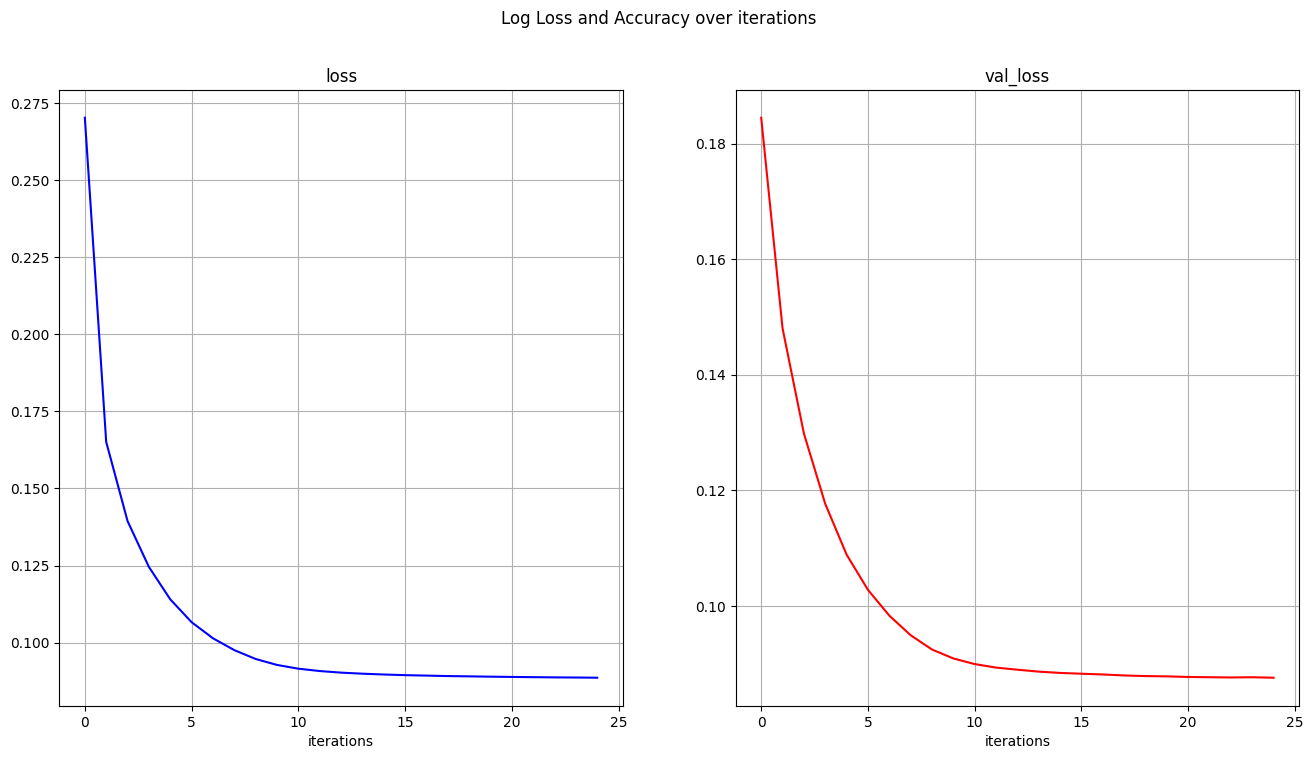

In [ ]:
graph_history(history, title='Log Loss and Accuracy over iterations')

In [ ]:
xhat=autoencoder.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 730us/step


In [ ]:
def plot_images(top,bottom,start=0,stop=5,reshape_x=(28,28),reshape_xhat=(28,28)):
    
    '''
    this function plots images from the start index to the stop index from two datasets
    
    '''

    n_samples=stop-start

    for i,img_index in enumerate(range(start,stop)):
        
        # Display original
        ax = plt.subplot(2, n_samples, i + 1)
        plt.imshow(top[img_index].reshape(reshape_x[0], reshape_x[1]), cmap="gray")

        if i==n_samples//2:
            plt.title("original images")

        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

        # Display reconstruction
        ax = plt.subplot(2, n_samples, i + 1 + n_samples)
        plt.imshow(bottom[img_index].reshape(reshape_xhat[0], reshape_xhat[1]), cmap="gray")


        if i==n_samples//2:
            plt.title("encoded images")

        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

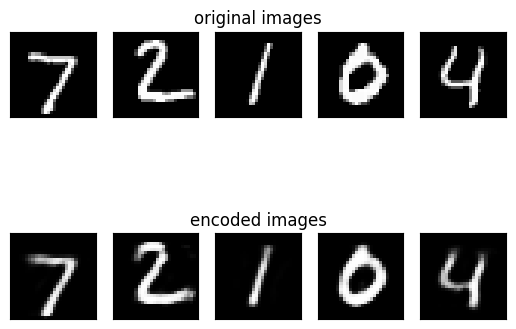

In [ ]:
plot_images(x_test,xhat,start=0,stop=5)

### Autoencoders using Model Subclassing




In [ ]:
class Autoencoder(tf.keras.Model):
    def __init__(self, latent_dim):
        super(Autoencoder, self).__init__()
        self.latent_dim = latent_dim   
        self.encoder = Dense(latent_dim, activation='relu')
        self.decoder = Dense(784, activation='sigmoid')

    def call(self, x):
        
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [ ]:
encoding_dim=36
autoencoder = Autoencoder(encoding_dim)

Epoch 1/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.2719 - val_loss: 0.1875
Epoch 2/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1659 - val_loss: 0.1483
Epoch 3/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1397 - val_loss: 0.1298
Epoch 4/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1244 - val_loss: 0.1172
Epoch 5/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1139 - val_loss: 0.1085
Epoch 6/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1067 - val_loss: 0.1026
Epoch 7/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1015 - val_loss: 0.0983
Epoch 8/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0978 - val_loss: 0.0952
Epoch 9/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0951 - val_loss: 0.0929
Epoch 10/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0931 - val_loss: 0.0913
Epoch 11/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0919 - val_loss: 0.0902
Epoch 12/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/st

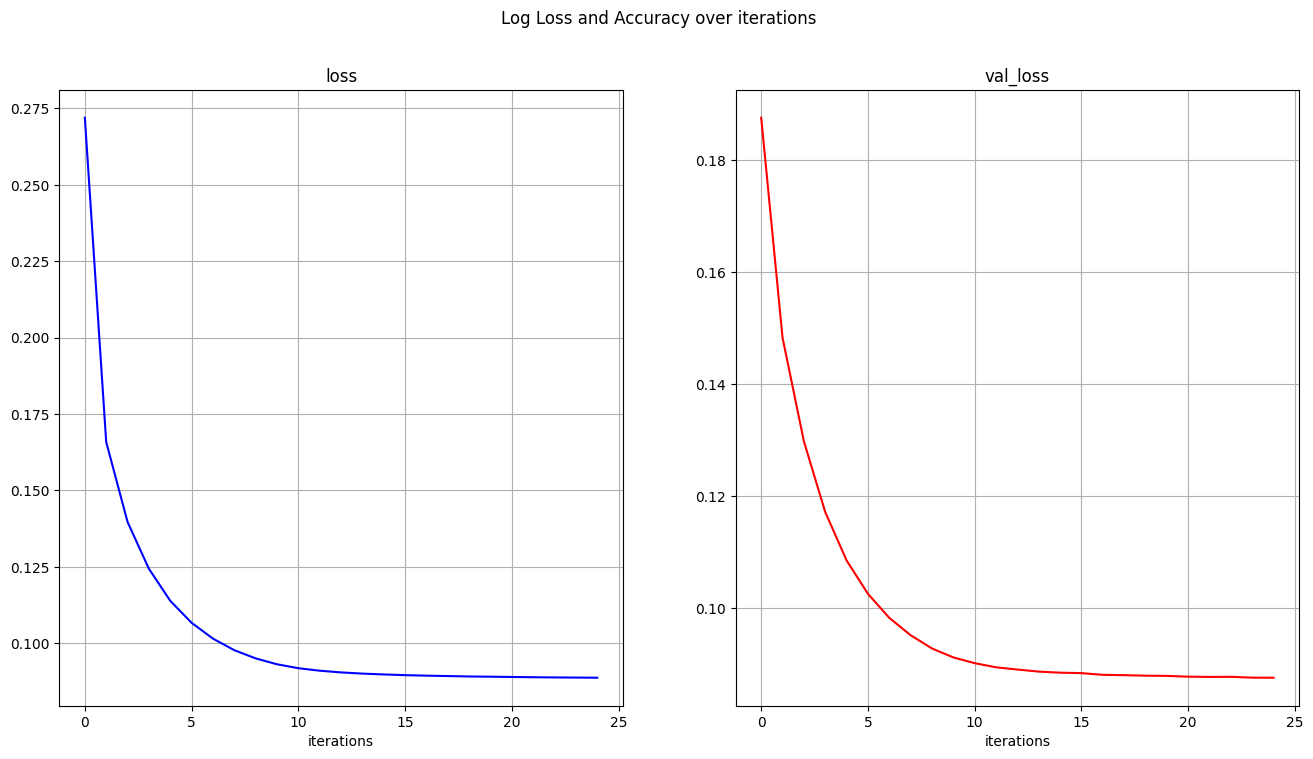

In [ ]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
history=autoencoder.fit(x_train, x_train,epochs=25,batch_size=256,shuffle=True,validation_data=(x_test, x_test))
graph_history(history, title='Log Loss and Accuracy over iterations')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


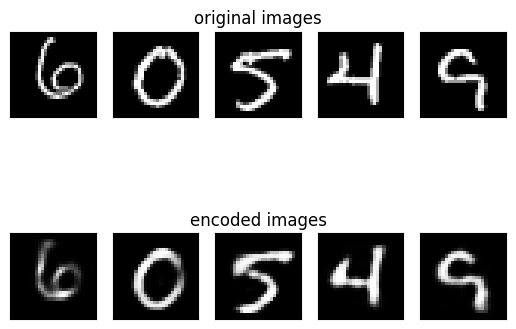

In [ ]:
xhat=autoencoder.predict(x_test)
plot_images(x_test,xhat,start=100,stop=105)

In [ ]:
h=autoencoder.encoder(x_test)
h.shape

TensorShape([10000, 36])

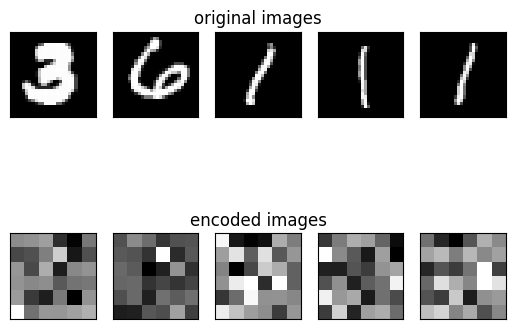

In [ ]:
plot_images(x_test, h.numpy(),start=200,stop=205,reshape_x=(28,28),reshape_xhat=(6,6))

In [ ]:
bce = tf.keras.losses.BinaryCrossentropy(from_logits=True)

In [ ]:
loss=[bce(x, x_s).numpy() for x, x_s in zip (x_test,xhat)]

In [ ]:
def add_noise(x_train, x_test, noise_factor = 0.3):
    '''
    this function adds random values from a normal distribution as noises to the data 
    
    returns the noisy datasets 
    
    '''
    noise_factor = 0.3
    x_train_noisy = x_train + noise_factor * tf.random.normal(shape=x_train.shape) 
    x_test_noisy = x_test + noise_factor * tf.random.normal(shape=x_test.shape) 

    x_train_noisy = tf.clip_by_value(x_train_noisy, clip_value_min=0., clip_value_max=1.).numpy()
    x_test_noisy = tf.clip_by_value(x_test_noisy, clip_value_min=0., clip_value_max=1.).numpy()
    
    return x_train_noisy,x_test_noisy

In [ ]:
x_train_noisy,x_test_noisy= add_noise(x_train, x_test,noise_factor = 0.4)

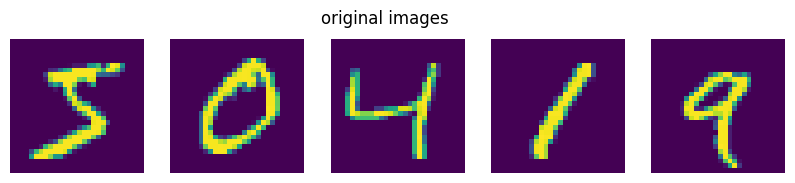

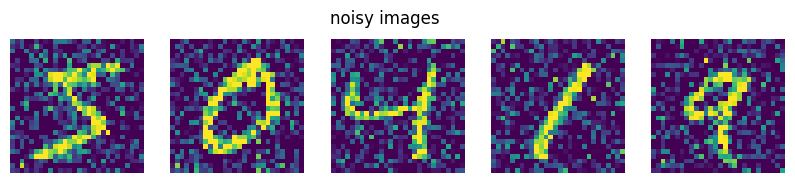

In [ ]:
np.random.seed(42)
fig1 = plt.figure(figsize=(10,2))
fig1.suptitle("original images")
fig2 = plt.figure(figsize=(10,2))
fig2.suptitle("noisy images")

for i, img_index in enumerate(range(5)):
    ax1 = fig1.add_subplot(1, 5, i+1)
    ax1.imshow(x_train[img_index].reshape((28,28)))
    ax1.axis("off")
    ax2 = fig2.add_subplot(1, 5, i+1)
    ax2.imshow(x_train_noisy[img_index].reshape((28,28)))
    ax2.axis("off")

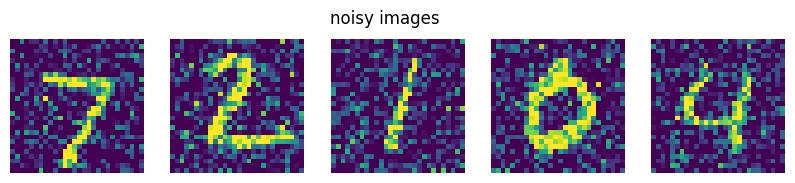

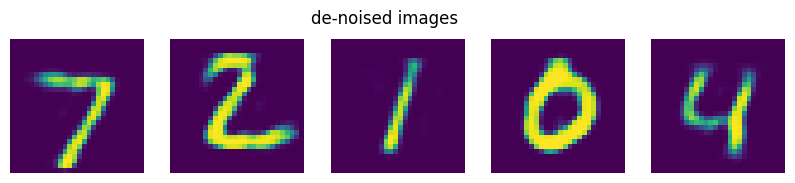

In [ ]:
np.random.seed(42)
fig1 = plt.figure(figsize=(10,2))
fig1.suptitle("noisy images")
fig2 = plt.figure(figsize=(10,2))
fig2.suptitle("de-noised images")

for i, img_index in enumerate(range(5)):
    ax1 = fig1.add_subplot(1, 5, i+1)
    ax1.imshow(x_test_noisy[img_index].reshape((28,28)))
    ax1.axis("off")
    ax2 = fig2.add_subplot(1, 5, i+1)
    ax2.imshow(xhat[img_index].reshape((28,28)))
    ax2.axis("off")

In [ ]:
x_train_flat = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test_flat = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))
print(x_train_flat.shape)
print(x_test_flat.shape)

(60000, 784)
(10000, 784)


In [ ]:
from sklearn.preprocessing import MinMaxScaler
s = MinMaxScaler().fit(x_train_flat)
x_train_scaled = s.transform(x_train_flat)

In [ ]:
from sklearn.decomposition import PCA

def mnist_pca(x_data, n_components):
    pca = PCA(n_components=n_components)

    fit_pca = pca.fit(x_data)
    
    print("Variance explained with {0} components:".format(n_components), 
          round(sum(fit_pca.explained_variance_ratio_), 2))

    return fit_pca, fit_pca.transform(x_data)

In [ ]:
pca_full, mnist_data_full = mnist_pca(x_train_scaled, 784)

Variance explained with 784 components: 1.0


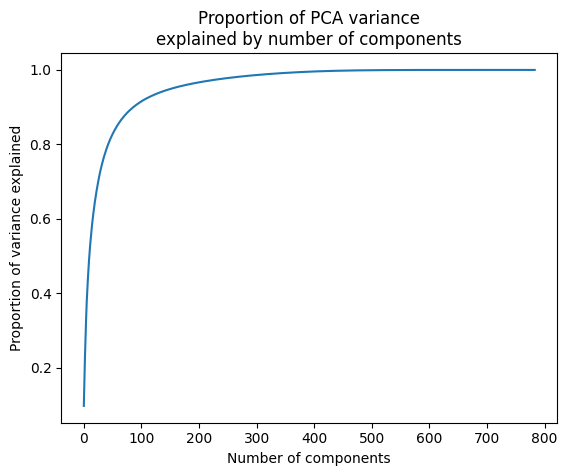

In [ ]:
plt.plot(np.cumsum(pca_full.explained_variance_ratio_))
plt.title("Proportion of PCA variance\nexplained by number of components")
plt.xlabel("Number of components")
plt.ylabel("Proportion of variance explained");

We need about 250 components to explain 90% of the variance in the data!


In [ ]:
pca_2, mnist_data_2 = mnist_pca(x_train_scaled, 2)

Variance explained with 2 components: 0.17


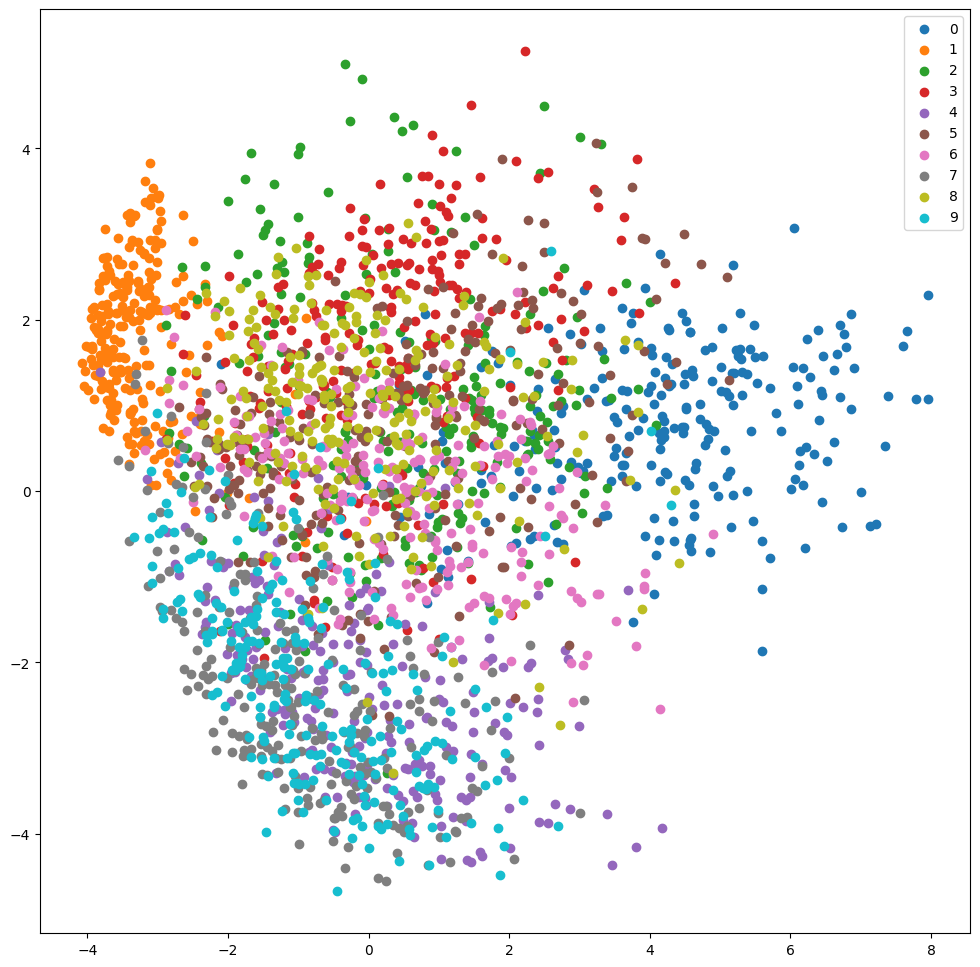

In [ ]:
num_images_per_class = 250
fig = plt.figure(figsize=(12,12))
for number in list(range(10)):
    mask = y_train == number
    x_data = mnist_data_2[mask, 0][:num_images_per_class]
    y_data = mnist_data_2[mask, 1][:num_images_per_class]
    plt.scatter(x_data, y_data, label=number, alpha=1)
plt.legend();

### one small project on autoencoder 

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, models

In [33]:
img = Image.open(r"C:\Users\BIT\Desktop\Education 1\SEM 7\SML2\archive\images\test\70090.jpg")

# Convert to grayscale and resize
img = img.convert("RGB")
img = img.resize((128, 128))

img = np.array(img).astype("float32") / 255.0

# Add channel dimension
img = img.reshape(1, 128, 128, 3)

print(img.shape)

(1, 128, 128, 3)


In [34]:
np.random.seed(42)

num_samples = 1000
noise_factor = 0.3

clean_images = np.repeat(img, num_samples, axis=0)

noise = noise_factor * np.random.normal(
    0, 1,
    clean_images.shape
)

noisy_images = clean_images + noise

noisy_images = np.clip(noisy_images, 0, 1)

In [35]:
noisy_images

array([[[[2.58818168e-01, 5.65599269e-02, 2.21757542e-01],
         [5.74556016e-01, 3.56363417e-02, 0.00000000e+00],
         [5.83567767e-01, 3.24348068e-01, 0.00000000e+00],
         ...,
         [0.00000000e+00, 3.12676584e-01, 9.02967210e-02],
         [6.96156568e-01, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

        [[0.00000000e+00, 1.39235785e-01, 1.37820912e-01],
         [6.68733606e-01, 3.83166369e-01, 0.00000000e+00],
         [0.00000000e+00, 2.33850264e-01, 0.00000000e+00],
         ...,
         [2.41465515e-01, 0.00000000e+00, 7.18970637e-02],
         [8.07241049e-01, 1.82408545e-02, 3.80076117e-01],
         [0.00000000e+00, 3.65622773e-02, 5.66534310e-01]],

        [[0.00000000e+00, 6.37852216e-01, 2.43698132e-01],
         [0.00000000e+00, 2.79918402e-01, 3.23138886e-01],
         [2.61052796e-01, 0.00000000e+00, 0.00000000e+00],
         ...,
         [7.29670553e-02, 2.98041395e-03, 4.38894019e-02],
         [

In [39]:
autoencoder = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    # Encoder
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2), padding="same"),

    layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2), padding="same"),

    # Decoder
    layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
    layers.UpSampling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.UpSampling2D((2, 2)),

    # RGB output
    layers.Conv2D(3, (3, 3), activation="sigmoid", padding="same")
])

In [40]:
autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

In [41]:
history = autoencoder.fit(
    noisy_images,
    clean_images,
    epochs=20,
    batch_size=32,
    shuffle=True,
    validation_split=0.2
)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 453ms/step - loss: 0.5816 - val_loss: 0.5378
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 410ms/step - loss: 0.5091 - val_loss: 0.4916
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 386ms/step - loss: 0.4893 - val_loss: 0.4871
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 402ms/step - loss: 0.4859 - val_loss: 0.4848
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 392ms/step - loss: 0.4839 - val_loss: 0.4829
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 378ms/step - loss: 0.4820 - val_loss: 0.4812
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 435ms/step - loss: 0.4806 - val_loss: 0.4802
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 418ms/step - loss: 0.4799 - val_loss: 0.4796
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 428ms/step - loss: 0.4794 - val_loss: 0.4792
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 407ms/step - loss: 0.4790 - val_loss: 0.4789
Epoch 11/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 376ms/step - loss: 0.4787 - val_loss: 0.4786
Epoch 12/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 

In [42]:
autoencoder.fit(noisy_images, clean_images)

32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 345ms/step - loss: 0.4775


In [43]:
np.random.seed(42)

test_noise = noise_factor * np.random.normal(
    0, 1,
    img.shape
)

test_noisy = np.clip(img + test_noise, 0, 1)

denoised = autoencoder.predict(test_noisy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step


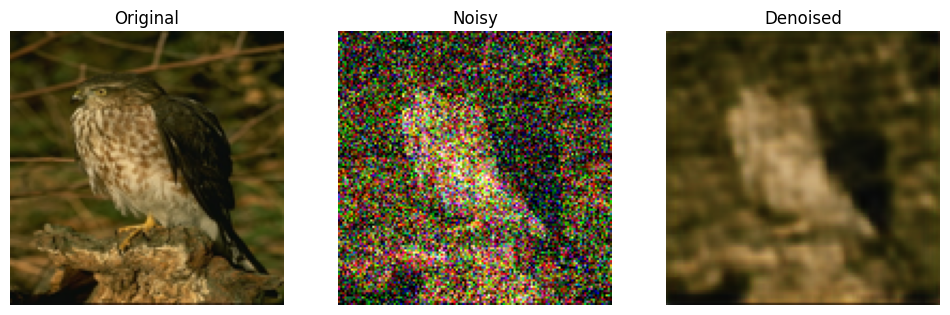

In [44]:
plt.figure(figsize=(12, 4))

# Original RGB image
plt.subplot(1, 3, 1)
plt.imshow(img[0])
plt.title("Original")
plt.axis("off")

# Noisy RGB image
plt.subplot(1, 3, 2)
plt.imshow(test_noisy[0])
plt.title("Noisy")
plt.axis("off")

# De-noised RGB image
plt.subplot(1, 3, 3)
plt.imshow(denoised[0])
plt.title("Denoised")
plt.axis("off")

plt.show()